# Hurricane Ian Trajectory Visualization and Routing Analysis

This notebook performs trajectory visualization and road network routing analysis for Hurricane Ian evacuation simulations in Florida.

## Table of Contents
1. **Data Loading & Preprocessing** - Load POI data with embeddings
2. **CRS Transformation** - Convert to Albers Equal Area projection
3. **Hurricane Impact Zone Definition** - Define affected counties
4. **Area Visualization** - Display impact zone on maps
5. **Trajectory Simulation** - Generate evacuation trajectories
6. **Interactive Map Generation** - Create Folium visualization
7. **CSV Export** - Export trajectory data
8. **Road Network Download** - Get OSM road network
9. **Route Generation** - Route trajectories on actual roads
10. **Analysis** - Examine individual trajectories

---

## 1. Import Required Libraries

In [5]:
import geopandas as gpd
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import folium
import os
import osmnx as ox
import networkx as nx

In [6]:
gdf = gpd.read_parquet("POI_encoded_embeddings.parquet")
print(gdf.head())

                                          label_pair  \
0  Activities Related to Real Estate[sep]Resident...   
1  Offices of Real Estate Agents and Brokers[sep]...   
2  Sporting Goods, Hobby, and Musical Instrument ...   
3        Offices of Dentists[sep]Offices of Dentists   
4  Museums, Historical Sites, and Similar Institu...   

                                                   z  \
0  [61.499184, 25.730932, 28.544409, 16.33576, 38...   
1  [10.239435, 8.276576, 44.785103, 72.61034, 19....   
2  [23.133112, 20.673256, 16.964842, 24.288828, 2...   
3  [21.774567, 62.81708, 77.10956, 94.822975, 61....   
4  [48.68053, 51.811516, -0.24616693, 46.184406, ...   

                     geometry  \
0  POINT (-82.52482 27.94908)   
1  POINT (-81.38077 30.19916)   
2   POINT (-81.76929 24.5666)   
3  POINT (-81.68255 30.20312)   
4  POINT (-81.84711 26.64202)   

                                            cat_name  cat_count  weight hex_id  
0                  Activities Related to Real 

## 2. Load POI Data with Embeddings

Load the POI dataset containing:
- `label_pair`: Category labels
- `z`: Embedding vectors
- `geometry`: Geographic coordinates (POINT)
- `cat_name`: Category names
- `cat_count`, `weight`, `hex_id`: Metadata

In [7]:
# We'll use a UTM projection suitable for Florida (EPSG:5070)
print(f"Original CRS: {gdf.crs}")
gdf = gdf.to_crs("EPSG:5070")
print(f"New CRS: {gdf.crs}. Units are now in meters.")

# Now, when you run your simulation, MAX_TRAVEL_DISTANCE will be in meters.
# For a 5km radius, you would set:
MAX_TRAVEL_DISTANCE = 5000  # 5000 meters = 5 km

Original CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "scope

In [8]:
# --- 1. Data Loading & Preprocessing ---
try:
    gdf = gpd.read_parquet("POI_encoded_embeddings.parquet")
    print("✅ Successfully loaded 'POI_encoded_embeddings.parquet'.")
except FileNotFoundError:
    print("❌ ERROR: 'POI_encoded_embeddings.parquet' not found.")
    exit()

gdf = gdf.reset_index(drop=True)

# --- 2. CRS Transformation & Geographic Data Integration ---
TARGET_CRS = "EPSG:5070"  # Albers Equal Area projection suitable for Florida
print("Projecting coordinates...")
gdf_proj = gdf.to_crs(TARGET_CRS) # Create a projected copy
print(f"CRS transformed to Albers Equal Area (meters).")

# --- 3. NEW: Load Population and Hurricane Impact Zone Data ---
print("\nLoading Florida county boundaries and population data...")
try:
    # Load all US county boundaries
    all_counties_gdf = gpd.read_file("https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json")
    
    # ‼️【MODIFICATION】First, filter for Florida counties ONLY
    # The 'STATE' column contains the state FIPS code. Florida's is '12'.
    fl_counties_gdf = all_counties_gdf[all_counties_gdf['STATE'] == '12'].copy()
    
    # Load Florida county population data
    # Ensure this file is in the same directory as your script
    population_df = pd.read_csv("florida_counties_population.csv") # Assumes 'County' and 'Population' columns
    
    # Merge population data into the county geodataframe
    fl_counties_gdf = fl_counties_gdf.merge(population_df, left_on='NAME', right_on='County', how='left')
    
    # Define counties most impacted by Hurricane Ian (names must match data)
    HURRICANE_IAN_COUNTIES = [
        'Lee', 'Charlotte', 'Sarasota', 'Collier', 'DeSoto', 
        'Hardee', 'Manatee', 'Polk', 'Hillsborough', 'Pinellas'
    ]
    
    # Filter for the specific impacted counties within Florida
    ian_zone_gdf = fl_counties_gdf[fl_counties_gdf['County'].isin(HURRICANE_IAN_COUNTIES)].copy()
    
    if ian_zone_gdf.empty:
        raise ValueError("Could not find any specified Hurricane Ian counties in the county data. Check names in HURRICANE_IAN_COUNTIES list.")
        
    print(f"✅ Successfully loaded and filtered {len(ian_zone_gdf)} counties in the Hurricane Ian impact zone.")

except Exception as e:
    print(f"❌ Failed to load external geographic or population data: {e}. Cannot continue.")
    exit()


✅ Successfully loaded 'POI_encoded_embeddings.parquet'.
Projecting coordinates...
CRS transformed to Albers Equal Area (meters).

Loading Florida county boundaries and population data...
✅ Successfully loaded and filtered 10 counties in the Hurricane Ian impact zone.


## 3. Data Loading & Geographic Setup

This section performs:
1. **Load POI data** - Read POI dataset with embeddings
2. **CRS Transformation** - Convert from WGS84 to Albers Equal Area (EPSG:5070) for accurate distance calculations in meters
3. **Load Geographic Data** - Load US county boundaries and filter for Florida
4. **Population Data** - Load county population for weighted initialization
5. **Define Impact Zone** - Specify Hurricane Ian affected counties

**Hurricane Ian Impact Counties:**
- Lee, Charlotte, Sarasota, Collier, DeSoto
- Hardee, Manatee, Polk, Hillsborough, Pinellas

In [9]:
ian_zone_gdf = ian_zone_gdf.to_crs(5070)  # Ensure CRS matches

/var/folders/sm/23kfy0px6sv9kq7gflc_rn3h0000gn/T/ipykernel_16505/1625720688.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  aoi_polygon = ian_zone_gdf.unary_union


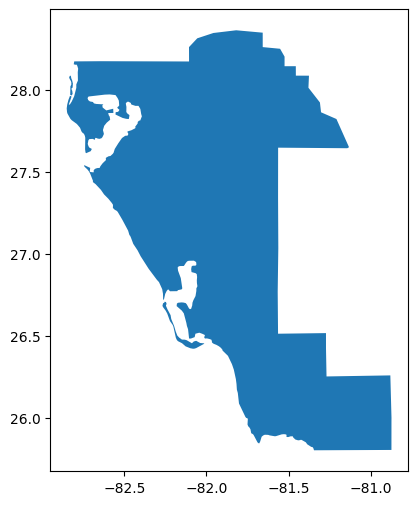

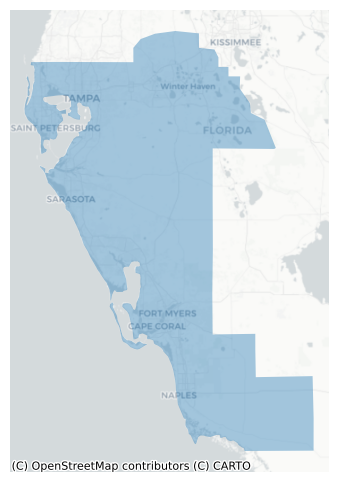

In [36]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Suppose you already have: from shapely.geometry import MultiPolygon
# multipoly = <your MultiPolygon>
aoi_polygon = ian_zone_gdf.unary_union
aoi_gs = gpd.GeoSeries([aoi_polygon])
aoi_gs = aoi_gs.set_crs(5070)
aoi_gs = aoi_gs.to_crs(4326)
ax = aoi_gs.plot(figsize=(6, 6), linewidth=1)
ax.set_aspect("equal")
plt.show()
import contextily as cx

gs3857 = aoi_gs # Web Mercator for tiles
ax = gs3857.plot(figsize=(6, 6), alpha=0.4, linewidth=1)
cx.add_basemap(ax, crs=4326, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
plt.show()

## 4. Visualize Hurricane Ian Impact Zone

Create visualizations of the affected area:
- Display county boundaries
- Add basemap for geographic context
- Show the 10-county hurricane impact zone

In [ ]:
# --- 4. Simulation Parameters ---
N_PEOPLE = 100
SIMULATION_DAYS = 7
DISTANCE_SCALE = 20000
# Multiplier to encourage long-distance evacuation to a different county.
COUNTY_WEIGHT_MULTIPLIER = {"same_county": 1.0, "diff_county": 3.0}

# --- 5. Archetype Definition & State Tracker Initialization ---
print("\nInitializing individuals in the impact zone based on population distribution...")

# ‼️【MODIFICATION】
# The key change is here. We perform a 'left' sjoin against ALL US counties.
# This keeps every POI in our dataset but tags each with its county name.
print("   - Assigning county information to all POIs in the dataset...")
gdf_proj = gpd.sjoin(gdf_proj, all_counties_gdf.to_crs(gdf_proj.crs)[['NAME', 'geometry']], how="left", predicate='within')

# Clean up columns and reset the index to prevent errors.
gdf_proj = gdf_proj.rename(columns={'NAME': 'County'})
gdf_proj = gdf_proj.drop(columns=['index_right'], errors='ignore')
gdf_proj = gdf_proj.reset_index(drop=True)

# we find home locations ONLY within the hurricane zone.
# This ensures everyone STARTS in the correct area.
home_locations = gdf_proj[
    (gdf_proj['cat_name'] == 'Activities Related to Real Estate') &
    (gdf_proj['County'].isin(HURRICANE_IAN_COUNTIES))
]

if home_locations.empty:
    raise ValueError("Could not find any 'Activities Related to Real Estate' POIs within the impact zone.")
else:
    print("✅ Successfully identified home locations in the impact zone.")

# This part remains the same, using ian_zone_gdf to determine population weights for starting counties.
county_weights = ian_zone_gdf.set_index('County')['Population']
county_probabilities = county_weights / county_weights.sum()

# Assign a home to each individual within the Ian Zone
initial_locations = []
for _ in range(N_PEOPLE):
    chosen_county = np.random.choice(county_probabilities.index, p=county_probabilities.values)
    homes_in_county = home_locations[home_locations['County'] == chosen_county]
    if not homes_in_county.empty:
        chosen_home_idx = np.random.choice(homes_in_county.index)
        initial_locations.append(chosen_home_idx)
    else:
        initial_locations.append(np.random.choice(home_locations.index))

people_df = pd.DataFrame({
    'person_id': range(N_PEOPLE),
    'status': 'at_home',
    'current_location_idx': initial_locations
})
people_df['home_location_idx'] = people_df['current_location_idx']
print(f"✅ Successfully assigned homes to {N_PEOPLE} individuals in the impact zone.")


# --- 6. Trajectory Generation & Simulation ---

HURRICANE_ARCHETYPES = {
    "prepping": {"start_cat": "Activities Related to Real Estate", "pattern": ["Grocery Stores", "Gasoline Stations", "Building Material and Supplies Dealers", "Activities Related to Real Estate"]},
    "evacuating": {"start_cat": "Activities Related to Real Estate", "pattern": ["Gasoline Stations", "Traveler Accommodation"]},
    "sheltering_in_place": {"start_cat": ["Activities Related to Real Estate", "Traveler Accommodation"], "pattern": ["Hospitals"]},
    "returning_home": {"start_cat": "Traveler Accommodation", "pattern": ["Gasoline Stations", "Activities Related to Real Estate"]},
    "post_storm_recovery": {"start_cat": "Activities Related to Real Estate", "pattern": ["Grocery Stores", "Building Material and Supplies Dealers", "Activities Related to Real Estate"]}
}

def generate_continuous_trajectory(start_idx, pattern):
    trajectory = [start_idx]
    current_poi_index = start_idx
    for target_category in pattern:
        # Candidate POIs can now be anywhere in the full dataset
        candidate_pois = gdf_proj[gdf_proj['cat_name'] == target_category]
        if candidate_pois.empty: break
            
        current_location = gdf_proj.loc[current_poi_index, 'geometry']
        # The current county can be NaN if the person is outside the initial county polygons, which is fine.
        current_county_name = gdf_proj.loc[current_poi_index, 'County']
        
        distances = candidate_pois.distance(current_location)
        weights = np.exp(-distances / DISTANCE_SCALE)
        
        # This logic now correctly encourages or discourages travel to a different county, anywhere in the US
        same_county_mask = candidate_pois['County'] == current_county_name
        weights[same_county_mask] *= COUNTY_WEIGHT_MULTIPLIER["same_county"]
        weights[~same_county_mask] *= COUNTY_WEIGHT_MULTIPLIER["diff_county"]
        
        weights += 1e-9
        probabilities = weights / weights.sum()
        if np.isnan(probabilities).all() or probabilities.sum() == 0: break
        next_poi_index = np.random.choice(candidate_pois.index, p=probabilities)
        trajectory.append(next_poi_index)
        current_poi_index = next_poi_index
    return trajectory

full_trajectories = {person_id: [] for person_id in range(N_PEOPLE)}
print(f"\nStarting 7-day continuous simulation for {N_PEOPLE} individuals...")
for day in range(1, SIMULATION_DAYS + 1):
    with tqdm(total=N_PEOPLE, desc=f"Simulating Day {day}") as pbar:
        for i, person in people_df.iterrows():
            status, current_location = person['status'], person['current_location_idx']
            action = None
            if day <= 2:
                if status == 'at_home': action = np.random.choice(["prepping", "evacuating"], p=[0.7, 0.3])
            elif day <= 4: action = "sheltering_in_place"
            else:
                if status == 'at_home': action = "post_storm_recovery"
                elif status == 'evacuated': action = "returning_home"
            daily_trajectory = []
            if action:
                archetype = HURRICANE_ARCHETYPES[action]
                daily_trajectory = generate_continuous_trajectory(current_location, archetype['pattern'])
            if not full_trajectories[person['person_id']] or full_trajectories[person['person_id']][-1][1] != current_location:
                 full_trajectories[person['person_id']].append((day, current_location))
            if daily_trajectory and len(daily_trajectory) > 1:
                full_trajectories[person['person_id']].extend([(day, idx) for idx in daily_trajectory[1:]])
                people_df.loc[i, 'current_location_idx'] = daily_trajectory[-1]
                if action == "evacuating": people_df.loc[i, 'status'] = 'evacuated'
                elif action == "returning_home" and daily_trajectory[-1] == person['home_location_idx']:
                    people_df.loc[i, 'status'] = 'at_home'
            pbar.update(1)
print("\n✅ Simulation complete!")

# --- 7. Visualization and 8. CSV Export (No changes needed) ---
# The rest of your code for visualization and CSV export will work correctly with these results.

# --- 7. Visualization ---
print("\nGenerating interactive GeoJSON highlight map...")
gdf_viz = gdf.to_crs("EPSG:4326")
map_center = [gdf_viz.geometry.y.mean(), gdf_viz.geometry.x.mean()]
features = []
POI_NAME_COLUMN = 'label_pair' 
for person_id, path_with_days in full_trajectories.items():
    if len(path_with_days) > 1:
        points = [(gdf_viz.loc[idx, 'geometry'].x, gdf_viz.loc[idx, 'geometry'].y) for day, idx in path_with_days]
        popup_html = f"<b>Trajectory for Person {person_id}</b><br><hr>"
        popup_html += "<table><tr><th>Day</th><th>Step</th><th>Location Name</th></tr>"
        for i, (day, poi_index) in enumerate(path_with_days):
            poi_name = gdf.loc[poi_index, POI_NAME_COLUMN]
            popup_html += f"<tr><td>{day}</td><td>{i+1}</td><td>{poi_name}</td></tr>"
        popup_html += "</table>"
        feature = {"type": "Feature","geometry": {"type": "LineString", "coordinates": points},"properties": {"person_id": f"Person {person_id}","popup_details": popup_html}}
        features.append(feature)
geojson_data = {"type": "FeatureCollection", "features": features}
m = folium.Map(location=map_center, zoom_start=8, tiles="cartodbpositron")
style_function = lambda x: {"color": "gray", "weight": 1.5, "opacity": 0.5}
highlight_function = lambda x: {"color": "#0077ff", "weight": 4, "opacity": 1.0}
interactive_layer = folium.GeoJson(
    geojson_data,
    style_function=style_function,
    highlight_function=highlight_function,
    tooltip=folium.GeoJsonPopup(fields=['person_id'], aliases=['']),
    popup=folium.GeoJsonPopup(fields=['popup_details'], aliases=[''])
)
m.add_child(interactive_layer)
output_filename = os.path.join("ian_zone_interactive_map.html")
m.save(output_filename)
print(f"🗺️  Interactive map based on Hurricane Ian impact zone and population saved to '{output_filename}'")

# --- 8. NEW: Export Trajectories to CSV ---
print("\nExporting trajectories to CSV file...")

# This list will store each step of each person's journey as a dictionary
trajectory_rows = []

# It's best to get coordinates in the standard WGS84 (lat/lon) format
# The sjoin operation added the 'County' column to gdf_proj, so we use that
gdf_proj_wgs84 = gdf_proj.to_crs("EPSG:4326")

# Loop through each person's complete trajectory
for person_id, path_with_days in tqdm(full_trajectories.items(), desc="Processing trajectories for CSV"):
    # Loop through each step in the person's path
    for i, (day, poi_index) in enumerate(path_with_days):
        
        # Get all the details for this specific POI from our GeoDataFrame
        poi_details = gdf_proj.loc[poi_index]
        poi_coords_wgs84 = gdf_proj_wgs84.loc[poi_index]

        # Create a dictionary representing one row in our final CSV
        row = {
            'person_id': person_id,
            'day': day,
            'step_order': i + 1,  # The sequence of stops for this person
            'poi_index': poi_index,
            'poi_name': poi_details['label_pair'],
            'poi_category': poi_details['cat_name'],
            'county': poi_details['County'], # County name was added via sjoin
            'latitude': poi_coords_wgs84.geometry.y,
            'longitude': poi_coords_wgs84.geometry.x
        }
        trajectory_rows.append(row)

# Convert the list of dictionaries into a pandas DataFrame
trajectories_df = pd.DataFrame(trajectory_rows)

# Define the output path and save the DataFrame to a CSV file
csv_output_filename = os.path.join("hurricane_ian_trajectories.csv")
trajectories_df.to_csv(csv_output_filename, index=False)

print(f"✅ Successfully saved trajectory data to '{csv_output_filename}'")
print("\nCSV file preview:")
print(trajectories_df.head())


Initializing individuals in the impact zone based on population distribution...
Checkpoint 1: Is the index unique right after loading the parquet file? -> False
   - DUPLICATES FOUND in the original file. Showing counts of duplicated index labels:
403905     2
343819     2
343748     2
343757     2
1233141    2
Name: count, dtype: int64
   - Fixing this by resetting the index now.
   - After immediate reset, is the index unique? -> True
Checkpoint 2: Is the index unique before the spatial join? -> True

   - Assigning county information to all POIs in the dataset...
Checkpoint 3: Is the index unique immediately after the spatial join? -> True
Checkpoint 4: Is the index unique after the final reset? -> True

Attempting to filter for home locations...
✅ Successfully filtered for home locations.
✅ Successfully assigned homes to 100 individuals in the impact zone.

Starting 7-day continuous simulation for 100 individuals...


Simulating Day 1:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating Day 2:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating Day 3:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating Day 4:   0%|          | 0/100 [00:00<?, ?it/s]

...

Simulating Day 6:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating Day 7:   0%|          | 0/100 [00:00<?, ?it/s]


✅ Simulation complete!

Generating interactive GeoJSON highlight map...
🗺️  Interactive map based on Hurricane Ian impact zone and population saved to 'ian_zone_interactive_map.html'

Exporting trajectories to CSV file...


Processing trajectories for CSV:   0%|          | 0/100 [00:00<?, ?it/s]

✅ Successfully saved trajectory data to 'hurricane_ian_trajectories.csv'

CSV file preview:
   person_id  day  step_order  poi_index  \
0          0    1           1    1385573   
1          0    1           2    1089425   
2          0    1           3     517995   
3          0    1           4    1179873   
4          0    1           5     169373   

                                            poi_name  \
0  Activities Related to Real Estate[sep]Resident...   
1  Grocery Stores[sep]Supermarkets and Other Groc...   
2  Gasoline Stations[sep]Gasoline Stations with C...   
3  Building Material and Supplies Dealers[sep]Har...   
4  Activities Related to Real Estate[sep]Resident...   

                             poi_category        county   latitude  longitude  
0       Activities Related to Real Estate      Pinellas  28.064453 -82.705534  
1                          Grocery Stores         Pasco  28.213709 -82.245832  
2                       Gasoline Stations  Hillsborough  28.118619

## 5. Hurricane Evacuation Simulation

### Simulation Parameters
- **N_PEOPLE**: 100 individuals
- **SIMULATION_DAYS**: 7 days
- **DISTANCE_SCALE**: 20km (controls travel distance preferences)
- **COUNTY_WEIGHT_MULTIPLIER**: Encourages evacuation to different counties (3x multiplier)

### Hurricane Behavior Archetypes

Five distinct behavior patterns:

1. **prepping** (Days 1-2, 70%): Grocery → Gas → Building Materials → Home
2. **evacuating** (Days 1-2, 30%): Gas → Traveler Accommodation
3. **sheltering_in_place** (Days 3-4): Hospital (if needed)
4. **returning_home** (Days 5-7): Gas → Home
5. **post_storm_recovery** (Days 5-7): Grocery → Building Materials → Home

### Trajectory Generation Algorithm
- Distance-based probabilistic selection: `weight = exp(-distance/DISTANCE_SCALE)`
- County multipliers encourage/discourage cross-county travel
- Continuous trajectories spanning multiple days

In [10]:
import osmnx as ox
import geopandas as gpd
# --- 1) Make sure AOI is in lon/lat (EPSG:4326) BEFORE union ---
ian_zone_gdf = ian_zone_gdf.to_crs(4326)
# Union to a single (Multi)Polygon
aoi_geom = ian_zone_gdf.unary_union  # shapely geometry (no CRS attached)
# Fix invalid geometry (self-intersections) if any
try:
    from shapely.validation import make_valid
    aoi_geom = make_valid(aoi_geom)       # Shapely ≥ 1.8/2.0
except Exception:
    aoi_geom = gpd.GeoSeries([aoi_geom], crs=4326).buffer(0).iloc[0]  # fallback
# Optional: lightly simplify to keep Overpass request manageable
aoi_geom = gpd.GeoSeries([aoi_geom], crs=4326)\
             .simplify(0.0002, preserve_topology=True).iloc[0]
# --- 2) Download the road network (pass the lon/lat geometry) ---
print("\nStep 2: Downloading the road network from OpenStreetMap...")
print("   - This may take a few minutes...")
# Optional but helpful settings
ox.settings.use_cache = True
ox.settings.log_console = True
ox.settings.requests_timeout = 180
try:
    G = ox.graph_from_polygon(
        aoi_geom,
        network_type="all",
        simplify=True,
        truncate_by_edge=True,   # clip at AOI boundary
        retain_all=False         # discard disconnected islands outside AOI
    )
    print(":white_check_mark: Road network graph downloaded successfully.")
except Exception as e:
    print(f":x: Failed to download graph. Error: {e}")
    # Fallback: try a bounding box (coarser but lighter)
    north, south, east, west = gpd.GeoSeries([aoi_geom], crs=4326).total_bounds[[3,1,2,0]]
    print("   → Trying bounding-box download as a fallback...")
    G = ox.graph_from_bbox(north, south, east, west, network_type="all", simplify=True)
    print(":white_check_mark: Road network (bbox) downloaded successfully.")


Step 2: Downloading the road network from OpenStreetMap...
   - This may take a few minutes...


/var/folders/sm/23kfy0px6sv9kq7gflc_rn3h0000gn/T/ipykernel_19878/2369915818.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  aoi_geom = ian_zone_gdf.unary_union  # shapely geometry (no CRS attached)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/osmnx/_overpass.py:271: UserWarning: This area is 14 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


:white_check_mark: Road network graph downloaded successfully.


## 6. Download Road Network from OpenStreetMap

Using OSMnx to download the road network for the Hurricane Ian impact zone:

**Process:**
1. Convert impact zone to WGS84 (EPSG:4326)
2. Union all counties into single polygon
3. Fix invalid geometries and simplify
4. Download from OpenStreetMap Overpass API
5. Handle large area (splits into sub-queries automatically)

**Network Settings:**
- `network_type="all"`: Include all road types
- `simplify=True`: Reduce unnecessary nodes
- `truncate_by_edge=True`: Clip at boundaries
- `retain_all=False`: Remove disconnected components

**Note:** This may take several minutes due to the large geographic area (14x the default query size).

In [12]:
# Save the graph as GraphML format
output_filename = "hurricane_ian_road_network.graphml"
ox.save_graphml(G, output_filename)

# Optionally, also save as a compressed format
compressed_filename = "hurricane_ian_road_network.gz"
ox.save_graph_geopackage(G, compressed_filename)

print(f"✅ Network graph saved to '{output_filename}' and '{compressed_filename}'")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: The filename extension should be 'gpkg' instead of 'gz' to conform to the GPKG specification.
  ogr_write(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: File hurricane_ian_road_network.gz has GPKG application_id, but non conformant file extension
  ogr_write(


✅ Network graph saved to 'hurricane_ian_road_network.graphml' and 'hurricane_ian_road_network.gz'


## 7. Save Road Network

Export the downloaded road network to multiple formats:

- **GraphML** (`hurricane_ian_road_network.graphml`): Standard graph format, easy to reload
- **GeoPackage** (`hurricane_ian_road_network.gz`): Compressed spatial format

These files can be reused to avoid re-downloading from OSM.

In [2]:
import osmnx as ox

graphml_path = "hurricane_ian_road_network.graphml"
G = ox.load_graphml(graphml_path)
print("✅ Loaded road network graph from GraphML file.")

✅ Loaded road network graph from GraphML file.


## 8. Load Saved Road Network

Load the previously saved road network graph from GraphML file.

This allows skipping the download step on subsequent runs.

In [ ]:
# --- imports (safe if repeated) ---
import os
import logging
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import networkx as nx
import geopandas as gpd
import osmnx as ox
from osmnx.routing import route_to_gdf
from shapely.ops import linemerge

# -------------------- logging --------------------
logging.basicConfig(
    filename="overlapping.log",
    filemode="w",                 # overwrite each run; change to "a" to append
    level=logging.INFO,
    format="%(message)s",
)
logging.info("Zero-length (overlapping) legs log\n")

# ===================== 3) Graph prep =====================
print("\nStep 3: Preparing graph (largest component, speeds/times)...")

if G.number_of_edges() == 0 or G.number_of_nodes() == 0:
    raise RuntimeError("The road graph is empty. Re-check the AOI / network_type / download step.")

# Keep only the largest (weakly) connected component
G = ox.truncate.largest_component(G, strongly=False)

# Add speeds & travel times if missing
if any('speed_kph' not in d for _, _, d in G.edges(data=True)):
    G = ox.add_edge_speeds(G)
if any('travel_time' not in d for _, _, d in G.edges(data=True)):
    G = ox.add_edge_travel_times(G)

# Component labels for quick feasibility checks
comp_id = {n: i for i, comp in enumerate(nx.weakly_connected_components(G)) for n in comp}

print("✅ Graph ready.")

# ===================== 4) Load / prepare trajectories =====================
if 'trajectories_df' not in locals():
    print("   - Loading trajectories from CSV...")
    trajectories_df = pd.read_csv("hurricane_ian_trajectories.csv")

trajectories_df = trajectories_df.sort_values(['person_id', 'step_order']).reset_index(drop=True)

# ---- 4.1 Vectorized edge-first snapping (once) ----
print("Snapping all trajectory points to nearest edges (vectorized)...")

Xs = trajectories_df['longitude'].to_numpy()
Ys = trajectories_df['latitude'].to_numpy()
edge_triplets = ox.distance.nearest_edges(G, Xs, Ys)  # list of (u,v,key)

u_ids = np.fromiter((t[0] for t in edge_triplets), dtype=object, count=len(edge_triplets))
v_ids = np.fromiter((t[1] for t in edge_triplets), dtype=object, count=len(edge_triplets))

ux = np.fromiter((G.nodes[u]['x'] for u in u_ids), dtype=float, count=len(u_ids))
uy = np.fromiter((G.nodes[u]['y'] for u in u_ids), dtype=float, count=len(u_ids))
vx = np.fromiter((G.nodes[v]['x'] for v in v_ids), dtype=float, count=len(v_ids))
vy = np.fromiter((G.nodes[v]['y'] for v in v_ids), dtype=float, count=len(v_ids))

# great-circle distances to each candidate endpoint (meters); vectorized
du = ox.distance.great_circle(Ys, Xs, uy, ux)
dv = ox.distance.great_circle(Ys, Xs, vy, vx)

snap_nodes = np.where(du <= dv, u_ids, v_ids)
trajectories_df['snap_node'] = snap_nodes

# ---- 4.2 Build leg requests ----
print("Building route requests...")

# raw next-step coordinates & POIs for logging and distance calc
trajectories_df['lon_next'] = trajectories_df.groupby('person_id')['longitude'].shift(-1)
trajectories_df['lat_next'] = trajectories_df.groupby('person_id')['latitude' ].shift(-1)
trajectories_df['dest_poi'] = trajectories_df.groupby('person_id')['poi_name'].shift(-1)

# snapped next nodes
trajectories_df['snap_node_next'] = trajectories_df.groupby('person_id')['snap_node'].shift(-1)
trajectories_df['step_next']      = trajectories_df.groupby('person_id')['step_order'].shift(-1)

pairs_df = trajectories_df.dropna(subset=['snap_node_next']).copy()
pairs_df['snap_node']      = pairs_df['snap_node'].astype(object)
pairs_df['snap_node_next'] = pairs_df['snap_node_next'].astype(object)

# Drop legs that are in different weak components (unreachable)
pairs_df = pairs_df[pairs_df['snap_node'].map(comp_id) == pairs_df['snap_node_next'].map(comp_id)]

# ---- Log & drop zero-length (same snapped node) legs ----
mask_same = pairs_df['snap_node'] == pairs_df['snap_node_next']
zero_len = pairs_df.loc[mask_same].copy()

def _osmid(n):
    val = G.nodes[n].get('osmid')
    if isinstance(val, (list, tuple)):
        return val[0]
    return val

if not zero_len.empty:
    # Node coordinates (lon=x, lat=y)
    zero_len['node_id']   = zero_len['snap_node']
    zero_len['node_osmid']= zero_len['snap_node'].map(_osmid)
    zero_len['node_x']    = zero_len['snap_node'].map(lambda n: G.nodes[n]['x'])
    zero_len['node_y']    = zero_len['snap_node'].map(lambda n: G.nodes[n]['y'])

    # Great-circle distance between original points (meters)
    zero_len['gc_m'] = ox.distance.great_circle(
        zero_len['latitude' ].to_numpy(), zero_len['longitude'].to_numpy(),
        zero_len['lat_next' ].to_numpy(), zero_len['lon_next' ].to_numpy()
    )

    cols = [
        'person_id','step_order','poi_name','dest_poi',
        'node_id','node_osmid','node_x','node_y',
        'longitude','latitude','lon_next','lat_next','gc_m'
    ]
    cols = [c for c in cols if c in zero_len.columns]

    logging.info(f"Skipping {len(zero_len)} zero-length legs (same snapped node). Details:")
    for _, r in zero_len[cols].iterrows():
        logging.info(
            "person_id=%s step=%s orig_poi=%s dest_poi=%s "
            "snap_node=%s osmid=%s node_x=%.6f node_y=%.6f "
            "orig_lon=%.6f orig_lat=%.6f dest_lon=%.6f dest_lat=%.6f gc_m=%.2f",
            r.get('person_id'), int(r.get('step_order')),
            str(r.get('poi_name')), str(r.get('dest_poi')),
            r.get('node_id'), str(r.get('node_osmid')),
            float(r.get('node_x')), float(r.get('node_y')),
            float(r.get('longitude')), float(r.get('latitude')),
            float(r.get('lon_next')), float(r.get('lat_next')),
            float(r.get('gc_m'))
        )

# Now drop them from routing
pairs_df = pairs_df[~mask_same]

print(f"Total legs to route (after filtering): {len(pairs_df)}")

# ===================== 5) Fast routing: ONE SSSP per origin, directed only =====================
print("Routing with single-source Dijkstra per origin (directed only)...")

all_routes_data = []

for o_node, group in tqdm(pairs_df.groupby('snap_node'), total=pairs_df['snap_node'].nunique()):
    # One Dijkstra for all reachable nodes from this origin
    dist_dir, paths_dir = nx.single_source_dijkstra(G, source=o_node, weight='travel_time')

    # Emit results for each leg in this origin group
    for _, row in group.iterrows():
        d_node = row['snap_node_next']
        route_nodes = paths_dir.get(d_node)   # None if unreachable (shouldn't happen after comp_id filter)
        if route_nodes is None or len(route_nodes) < 2:
            continue

        edges_gdf  = route_to_gdf(G, route_nodes, weight='travel_time')  # edges in order
        route_geom = linemerge(list(edges_gdf.geometry))
        total_time_s = float(edges_gdf['travel_time'].sum())
        total_len_m  = float(edges_gdf['length'].sum())

        # Also compute straight-line (great-circle) distance between original points
        gc_m = float(ox.distance.great_circle(
            row['latitude'], row['longitude'],
            row['lat_next'], row['lon_next']
        ))

        all_routes_data.append({
            'person_id' : row['person_id'],
            'step'      : int(row['step_order']),
            'origin_poi': row.get('poi_name', None),
            'dest_poi'  : row.get('dest_poi', None),
            'mode'      : "directed",
            'travel_s'  : total_time_s,
            'length_m'  : total_len_m,   # network distance in meters
            'gc_m'      : gc_m,          # straight-line distance in meters
            'geometry'  : route_geom
        })

print("\n✅ Routing complete.")
print("Zero-length leg details (if any) were written to overlapping.log")

# ===================== 6) Save =====================
print("\nStep 5: Converting routes to GeoDataFrame and saving...")
if all_routes_data:
    routes_gdf = gpd.GeoDataFrame(all_routes_data, crs="EPSG:4326")
    routes_gdf.to_parquet("hurricane_ian_routes.parquet")
    print("Saved to hurricane_ian_routes.parquet")
    print(routes_gdf.head())
else:
    print("   - No routes were generated, so no file was saved.")


Step 3: Calculating edge speeds and travel times for routing...
:white_check_mark: Travel times calculated and added to the graph.

Step 4: Preparing to generate routes for each person's trajectory...


Generating Routes:   0%|          | 0/100 [00:00<?, ?it/s]


----------------------------------------------------
-> Processing: Person 0, Step 1
   Origin POI: Activities Related to Real Est... at (28.064453000000047, -82.70553400000001)
   Dest.  POI: Grocery Stores[sep]Supermarket... at (28.21370899999999, -82.245832)
   Mapped Origin Node: 6358541288
   Mapped Dest.  Node: 99667903
   Path Found: [6358541288, 99792937, 99792939, 100003656, 100003660]... (Total 238 nodes)
   Path Length (node count): 238

----------------------------------------------------
-> Processing: Person 0, Step 2
   Origin POI: Grocery Stores[sep]Supermarket... at (28.21370899999999, -82.245832)
   Dest.  POI: Gasoline Stations[sep]Gasoline... at (28.11861899999999, -82.378824)
   Mapped Origin Node: 99667903
   Mapped Dest.  Node: 97823621
   Path Found: [99667903, 6665641707, 976339167, 97781332, 97836710]... (Total 44 nodes)
   Path Length (node count): 44

----------------------------------------------------
-> Processing: Person 0, Step 3
   Origin POI: Gasolin

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1056895d0>>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 



----------------------------------------------------
-> Processing: Person 0, Step 15
   Origin POI: Grocery Stores[sep]Convenience... at (28.121882000000003, -80.65811600000002)
   Dest.  POI: Building Material and Supplies... at (28.35834299999999, -80.691879)
   Mapped Origin Node: 2141665064
   Mapped Dest.  Node: 99986609
   Path Found: [2141665064, 969987131, 969987133, 4856584805, 100148381]... (Total 9 nodes)
   Path Length (node count): 9
--- SKIPPING --- Person: 0, Step: 16 -> Origin and destination nodes are identical (99986609).
   Origin POI: Building Material and Supplies... at (28.35834299999999, -80.691879)
   Dest.  POI: Activities Related to Real Est... at (28.22912899999996, -80.70300000000002)
   Mapped Origin Node: 99986609
   Mapped Dest.  Node: 99986609

----------------------------------------------------
-> Processing: Person 0, Step 17
   Origin POI: Activities Related to Real Est... at (28.22912899999996, -80.70300000000002)
   Dest.  POI: Grocery Stores[sep

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1056895d0>>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 



----------------------------------------------------
-> Processing: Person 1, Step 9
   Origin POI: Activities Related to Real Est... at (28.03656799999999, -81.956847)
   Dest.  POI: Hospitals[sep]<null_val>... at (27.49792100000004, -82.560411)
   Mapped Origin Node: 100173701
   Mapped Dest.  Node: 98868961
   Path Found: [100173701, 100386466, 100132040, 100078684, 100242882]... (Total 152 nodes)
   Path Length (node count): 152

----------------------------------------------------
-> Processing: Person 1, Step 10
   Origin POI: Hospitals[sep]<null_val>... at (27.49792100000004, -82.560411)
   Dest.  POI: Hospitals[sep]<null_val>... at (27.92503599999993, -82.506196)
   Mapped Origin Node: 98868961
   Mapped Dest.  Node: 97765070
   Path Found: [98868961, 98868963, 98756413, 98745543, 98745542]... (Total 107 nodes)
   Path Length (node count): 107

----------------------------------------------------
-> Processing: Person 1, Step 11
   Origin POI: Hospitals[sep]<null_val>... at (2

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1056895d0>>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


--- SKIPPING --- Person: 2, Step: 3 -> Origin and destination nodes are identical (1649539435).
   Origin POI: Gasoline Stations[sep]Other Ga... at (28.540090999999997, -81.377685)
   Dest.  POI: Building Material and Supplies... at (28.54353600000005, -81.399004)
   Mapped Origin Node: 1649539435
   Mapped Dest.  Node: 1649539435
--- SKIPPING --- Person: 2, Step: 4 -> Origin and destination nodes are identical (1649539435).
   Origin POI: Building Material and Supplies... at (28.54353600000005, -81.399004)
   Dest.  POI: Activities Related to Real Est... at (28.540948000000004, -81.378721)
   Mapped Origin Node: 1649539435
   Mapped Dest.  Node: 1649539435


## 9. Route Generation on Road Network

### Process Overview:
1. **Graph Preparation**
   - Filter to largest connected component
   - Add speed estimates and travel times
   - Identify weakly connected components

2. **Load Trajectories**
   - Read from CSV export
   - Sort by person and step order

3. **Vectorized Snapping**
   - Snap all POI locations to nearest road edges
   - Choose nearest node (u or v) for each edge
   - Significantly faster than iterative snapping

4. **Build Route Requests**
   - Create origin-destination pairs
   - Filter out unreachable pairs (different components)
   - Log zero-length legs (same snapped node)

5. **Efficient Routing with SSSP**
   - Group legs by origin node
   - **One Dijkstra call per unique origin**
   - Reuse results for all destinations from that origin
   - Calculate network distance, travel time, and straight-line distance

6. **Export Results**
   - Save to `hurricane_ian_routes.parquet`
   - Includes route geometries, distances, and travel times
   - Log problematic legs to `overlapping.log`

### Key Metrics:
- **length_m**: Network distance (meters) - actual road distance
- **gc_m**: Great-circle distance (meters) - straight-line distance  
- **travel_s**: Estimated travel time (seconds)
- **Circuity ratio**: length_m / gc_m

In [7]:
trajectories_df = pd.read_csv("hurricane_ian_trajectories.csv")

## 10. Analyze Individual Trajectories

Load the trajectory CSV to examine specific individuals' paths.

In [9]:
trajectories_df[trajectories_df['person_id'] == 2]

,person_id,day,step_order,poi_index,poi_name,poi_category,county,latitude,longitude
40,2,1,1,1226070,Activities Related to Real Estate[sep]Resident...,Activities Related to Real Estate,Hillsborough,28.083833,-82.460271
41,2,1,2,1265702,Grocery Stores[sep]Supermarkets and Other Groc...,Grocery Stores,Lake,28.548050,-81.708253
42,2,1,3,1526450,Gasoline Stations[sep]Other Gasoline Stations,Gasoline Stations,Orange,28.540091,-81.377685
43,2,1,4,1377415,Building Material and Supplies Dealers[sep]Hom...,Building Material and Supplies Dealers,Orange,28.543536,-81.399004
44,2,1,5,1543045,Activities Related to Real Estate[sep]Resident...,Activities Related to Real Estate,Orange,28.540948,-81.378721
45,2,2,6,1651702,Grocery Stores[sep]Supermarkets and Other Groc...,Grocery Stores,Hillsborough,27.833386,-82.328292
46,2,2,7,737909,Gasoline Stations[sep]Gasoline Stations with C...,Gasoline Stations,Pasco,28.273446,-82.179473
47,2,2,8,214464,Building Material and Supplies Dealers[sep]Pai...,Building Material and Supplies Dealers,Sumter,28.916145,-82.037733
48,2,2,9,797038,Activities Related to Real Estate[sep]Other Ac...,Activities Related to Real Estate,Lake,28.915652,-81.932208
49,2,3,10,227682,Hospitals[sep]<null_val>,Hospitals,Osceola,28.263765,-81.617741


### Example: Person 2's Evacuation Journey

View a single person's complete 7-day trajectory:
- Shows day-by-day progression
- Lists all visited POIs with categories
- Displays county-level movement patterns
- Reveals evacuation behavior (e.g., moving north from coastal areas)